#Introducción: Descripción del problema y objetivo del modelo

Para este proyecto práctico, abordaremos un problema de clasificación de imágenes de prendas de vestir utilizando el reconocido dataset Fashion-MNIST.

El dataset está compuesto por 70.000 imágenes en escala de grises con una resolución estandarizada de 28x28 píxeles. Estas imágenes se dividen en 60.000 muestras para el entrenamiento del modelo y 10.000 muestras exclusivas para la prueba y validación. El objetivo predictivo cuenta con 10 categorías distintas , que incluyen prendas como camisetas, pantalones, suéteres, vestidos, abrigos y distintos tipos de calzado y accesorios.

el proyecto tiene como objetivo principal implementar una Red Neuronal Artificial del tipo Perceptrón Multicapa (MLP) para la solución de este problema de clasificación multiclase.

#Carga de datos

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



(imgs_train,labs_train), (imgs_test,labs_test) = fashion_mnist.load_data()
print(imgs_train.shape)
print(imgs_test.shape)
nombres = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

(60000, 28, 28)
(10000, 28, 28)


En esta sección se inicializa el entorno de trabajo y se preparan los datos para la red neuronal:

Librerías: Se cargan tensorflow.keras, numpy, pandas y matplotlib. Estas son esenciales para construir el modelo, manipular arreglos numéricos y visualizar resultados.

Carga del Dataset: Se utiliza fashion_mnist.load_data() para obtener el conjunto de datos de entrenamiento (60,000 imágenes) y prueba (10,000 imágenes) de 28x28 píxeles.

Definición de Etiquetas: Se crea una lista llamada nombres que mapea los índices numéricos a categorías de ropa legibles (ej: 'Camiseta/Top', 'Bolso', 'Botín').

# Visualizacion

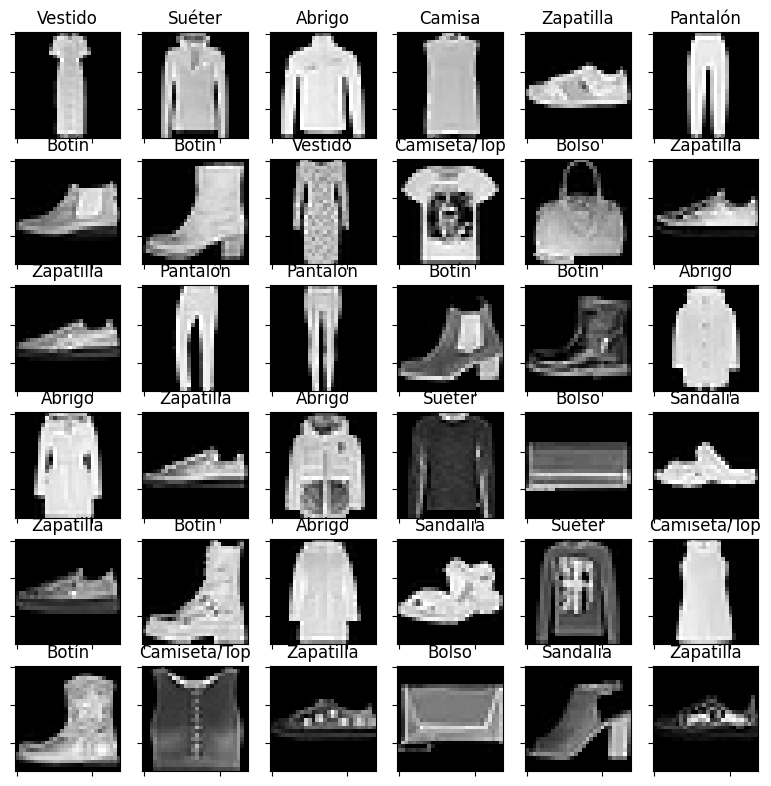

In [ ]:
h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(1.6*h,1.6*w))
for i in range(h):
  for j in range(w):
    ex = np.random.randint(len(imgs_test))
    axs[i,j].set_title(nombres[labs_test[ex]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(imgs_test[ex], cmap='gray')

Aqui se crea una cuadrícula de 6x6 (36 imágenes) usando plt.subplots.

 Ademas, se utiliza np.random.randint para seleccionar imágenes al azar del set de prueba, mostrando la imagen en escala de grises (cmap='gray') y asignando su etiqueta correspondiente como título. Esto permite validar visualmente que los datos se cargaron correctamente.

#Validacion de datos

In [ ]:
import numpy as np
print(f"\n1. Dimensiones:")
print(f"   Imágenes de entrenamiento: {imgs_train.shape} ({imgs_train.shape[0]} muestras de {imgs_train.shape[1]}x{imgs_train.shape[2]} píxeles)")
print(f"   Imágenes de prueba:        {imgs_test.shape} ({imgs_test.shape[0]} muestras de {imgs_test.shape[1]}x{imgs_test.shape[2]} píxeles)")
print(f"   Etiquetas de entrenamiento:{labs_train.shape}")
print(f"   Etiquetas de prueba:       {labs_test.shape}")

print(f"\n2. Búsqueda de valores nulos:")
nulos_train = np.isnan(imgs_train).sum()
nulos_test = np.isnan(imgs_test).sum()
if nulos_train == 0 and nulos_test == 0:
    print("Dataset limpio")
else:
    print(f"Se encontraron {nulos_train} nulos en train y {nulos_test} en test")


print(f"\n3. Rango de píxeles original (debe ser de 0 a 255):")
print(f"   Set Entrenamiento -> Mínimo: {imgs_train.min()} | Máximo: {imgs_train.max()}")
print(f"   Set Prueba        -> Mínimo: {imgs_test.min()} | Máximo: {imgs_test.max()}")


print(f"\n4. Clases objetivo (Labels):")
clases_unicas = np.unique(labs_train)
conteo_clases = np.bincount(labs_train)
print(f"   Categorías identificadas: {len(clases_unicas)} clases (Del {clases_unicas.min()} al {clases_unicas.max()})")
print("   Distribución de imágenes por clase en el set de entrenamiento:")
for clase, cantidad in zip(clases_unicas, conteo_clases):
    print(f"      - Clase {clase}: {cantidad} imágenes")


1. Dimensiones:
   Imágenes de entrenamiento: (60000, 28, 28) (60000 muestras de 28x28 píxeles)
   Imágenes de prueba:        (10000, 28, 28) (10000 muestras de 28x28 píxeles)
   Etiquetas de entrenamiento:(60000,)
   Etiquetas de prueba:       (10000,)

2. Búsqueda de valores nulos:
Dataset limpio

3. Rango de píxeles original (debe ser de 0 a 255):
   Set Entrenamiento -> Mínimo: 0 | Máximo: 255
   Set Prueba        -> Mínimo: 0 | Máximo: 255

4. Clases objetivo (Labels):
   Categorías identificadas: 10 clases (Del 0 al 9)
   Distribución de imágenes por clase en el set de entrenamiento:
      - Clase 0: 6000 imágenes
      - Clase 1: 6000 imágenes
      - Clase 2: 6000 imágenes
      - Clase 3: 6000 imágenes
      - Clase 4: 6000 imágenes
      - Clase 5: 6000 imágenes
      - Clase 6: 6000 imágenes
      - Clase 7: 6000 imágenes
      - Clase 8: 6000 imágenes
      - Clase 9: 6000 imágenes


Antes de comenzar a entrenar el modelo, hicimos una revisión rápida pero exhaustiva del dataset Fashion-MNIST utilizando NumPy llegando a las siguientes conclusiones:


-Estructura correcta: Confirmamos que tenemos exactamente las 60.000     imágenes para entrenar y 10.000 para probar, todas con la resolución esperada de 28x28 píxeles

-Cero datos corruptos: Comprobamos que no hubiera ningún valor vacío o nulo  que pudiera romper el código más adelante. Además, verificamos que la intensidad de los píxeles estuviera en su rango normal de 0 a 255.

-Verificamos que cada una de las 10 categorías de ropa tiene exactamente 6.000 imágenes de ejemplo. Al tener un dataset tan bien balanceado, nos aseguramos de que la red neuronal no genere un sesgo o preferencia hacia ninguna prenda en particular


# division datos train y test junto a transformacion a vector

In [ ]:
# Tranformamos los datos para el entrenamiento,
# Necesitamos transformar tanto el train como el test

X_train = imgs_train.reshape(60000,28*28)
X_test = imgs_test.reshape(10000,28*28)
X_train = X_train / 255
X_test = X_test / 255
print('X', X_train.shape, X_test.shape)

Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)
print('Y', Y_train.shape, Y_test.shape)

X (60000, 784) (10000, 784)
Y (60000, 10) (10000, 10)


En este módulo, se realiza la preparación del espacio de características. La vectorización adapta la geometría de los datos a la arquitectura MLP, la normalización garantiza la eficiencia del descenso de gradiente al mantener los pesos en rangos controlados, y las etiquetas (One-Hot) permite que la función de costo evalúe correctamente la probabilidad de pertenencia a cada una de las 10 categorías de Fashion MNIST.

Sin estos pasos, el modelo tendría un desempeño significativamente inferior o incluso fallaría al intentar entrenar.

# Primer modelo (descenso del gradiente, 4 layers)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Se fija una semilla o números "aleatorios" iniciales para que sean siempre los mismos cada vez que se ejecuta el código.

Lo que nos garantiza la reproducibilidad. Sin esto, cada vez que se entrenara el modelo se obtendria resultados distintos. Se crea el modelo base de tipo feed forward, donde la información fluye exclusivamente hacia adelante a través de las capas

Capas Ocultas: Utiliza tres capas con funciones de activación ReLU. La ReLU es el estándar de oro aquí porque ayuda a que el modelo aprenda más rápido y evita el desvanecimiento del gradiente.

Capa de Salida: Tiene 10 neuronas con activación Softmax. Esto convierte las salidas de la red en una distribución de probabilidad (la suma de las 10 salidas será 1), permitiendo clasificar la entrada en una de las 10 categorías posibles dichas anteriormente.

Para este primer modelo, se construyo una red neuronal básica dividida en cuatro capas. La estructura comienza recibiendo los datos de entrada y pasándolos por capas ocultas de 512 y 256 neuronas, lo que permite que el modelo "aprenda" patrones importantes de forma gradual. Usamos la función ReLU en estas capas porque ayuda a que el entrenamiento sea más rápido y eficiente, mientras que en la última capa usamos Softmax para que el resultado final sea una probabilidad que nos indique a qué categoría pertenece el objeto analizado. Finalmente, configuramos el modelo con el optimizador SGD y una función de error Categorical Crossentropy en este caso, con estas herramientas la red podra corregir sus errores paso a paso basándose en los 601,610 parámetros que debera ajustar

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp1_sgd_150ep.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6855 - loss: 1.0282 - val_accuracy: 0.7629 - val_loss: 0.6944
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7975 - loss: 0.5997 - val_accuracy: 0.7970 - val_loss: 0.5795
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8184 - loss: 0.5226 - val_accuracy: 0.8123 - val_loss: 0.5313
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8306 - loss: 0.4857 - val_accuracy: 0.8213 - val_loss: 0.5065
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8381 - loss: 0.4623 - val_accuracy: 0.8255 - val_loss: 0.4903
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8444 - loss: 0.4450 - val_accuracy: 0.8305 - val_loss: 0.4783
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8500 - loss: 0.4311 - val_accuracy: 0.8355 - val_loss: 0.4683
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8543 - loss: 0.4194 - val_accu

En este bloque, se realiza el entrenamiento del modelo, que es el proceso de aprendizaje a partir de los datos. Se configuraron tres parámetros clave: las épocas (150), que son las veces que el modelo revisará el conjunto de datos completo y el tamaño de batch (128), y los datos de validación, que sirven para evaluar qué tan bien está aprendiendo la red. Al ejecutar este código, el modelo entrega un historial de su progreso (guardado en la variable hist)

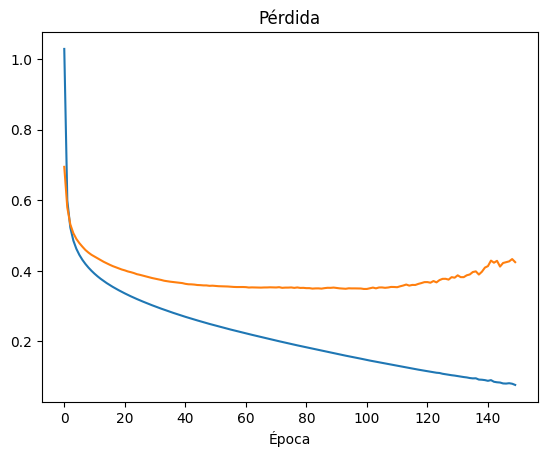

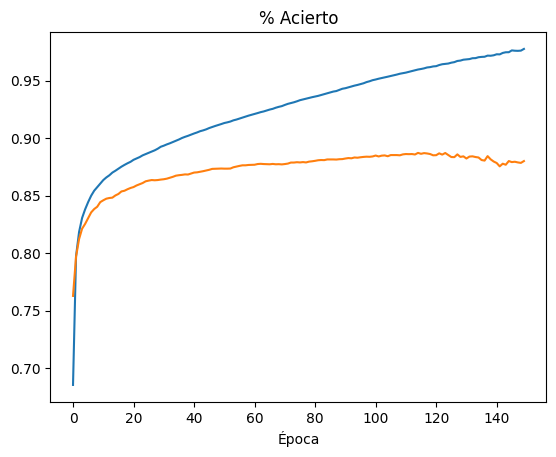

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

A través de estas gráficas, podemos visualizar una comparación entre el aprendizaje con los datos de entrenamiento y los datos de prueba, la gráfica de Pérdida muestra cómo disminuye el error, mientras que la de % Acierto revela qué tan bien está clasificando el modelo a medida que pasan las épocas:

Gráfica de Pérdida (Loss): El entrenamiento baja de forma constante, lo que indicaria que el modelo está aprendiendo a reducir su error interno. por otro lado, la validación deja de bajar cerca de la época 60 y comienza a subir ligeramente al final. Esto nos dice que el modelo se está volviendo muy bueno para memorizar los datos de práctica, pero le está costando mantener esa precisión con datos nuevos

Gráfica de % Acierto: Aqui vemos que el acierto en el entrenamiento llega casi al 95%, pero el acierto en la validación se estanca alrededor del 85%. Esta brecha entre ambas líneas nos indican que existe un overfitting (sobreajuste), lo que indica que el modelo no está generalizando de forma correcta

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.82      0.84      0.83      1000
    Pantalón       0.98      0.98      0.98      1000
      Suéter       0.87      0.70      0.78      1000
     Vestido       0.92      0.84      0.88      1000
      Abrigo       0.69      0.93      0.79      1000
    Sandalia       0.97      0.96      0.97      1000
      Camisa       0.74      0.67      0.70      1000
   Zapatilla       0.94      0.96      0.95      1000
       Bolso       0.97      0.96      0.96      1000
       Botín       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



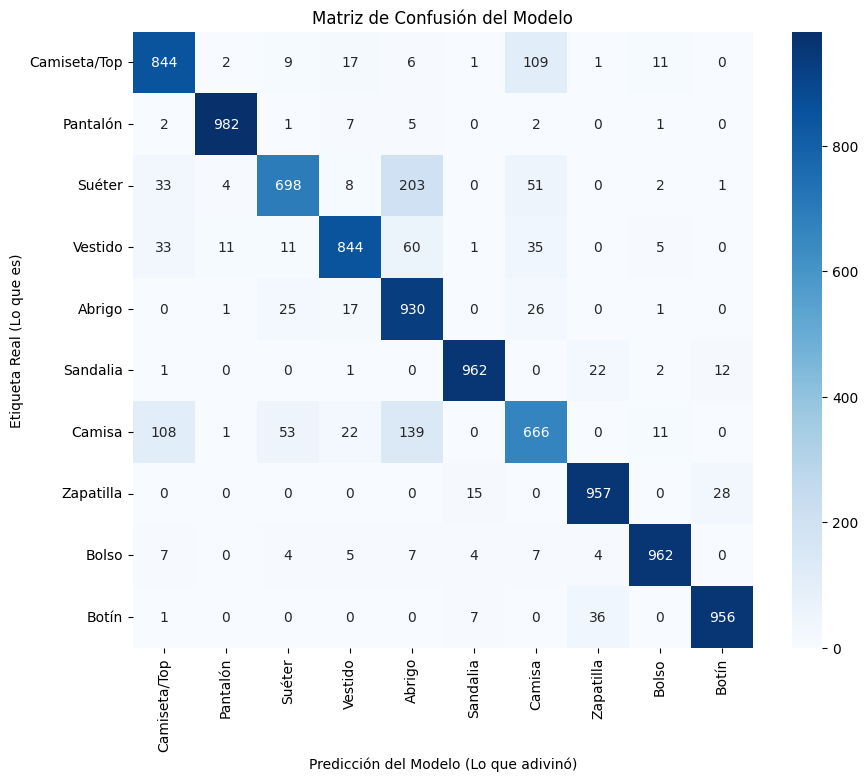

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

Por ultimo generamos un Cuadro Resumen de Métricas que nos entrega lo siguiente, la Precisión(que tanto acerto), el Recall (erroneos) y el F1-Score por cada tipo de prenda. Luego lo graficamos en una matriz de confusion,este primer modelo tuvo un desempeño aceptable, logrando una precision general (accuracy) del 89%, siendo eficiente para reconocer prendas fáciles de distinguir como Pantalones y Bolsos, donde alcanzó un 0.98 y 0.96 de precisión. pero presento dificultades con las Camisa (74% ) y el Abrigo(69%), confundiéndolos con Suéteres y Camisetas, como muestra la matriz de confusión.

# Segundo modelo (descenso del gradiente, 4 layers,Dropout)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='sgd',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Para este segundo modelo, hemos mantenido la estructura base del primero pero introduciendo una mejora, la técnica de regularización de Dropout. En este código, añadimos capas de Dropout que "apagan" aleatoriamente un porcentaje de neuronas (30% en la primera capa y 20% en la segunda) durante cada paso del entrenamiento. Hacemos esto para obligar a la red a no depender de neuronas específicas y así evitar que simplemente memorice los datos, evitando que este modelo se sobreajuste que el modelo anterior(primer modelo). Tal como muestra el resumen del modelo, esta pequeña modificación nos da una estrategia de optimización mejor. Al compilar con SGD y Categorical Crossentropy, se preparada una red que busca ser más estable y generalizar mejor ante imágenes nuevas o datos nuevos.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp2_sgd_150ep_Dropout.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5858 - loss: 1.2419 - val_accuracy: 0.7350 - val_loss: 0.7275
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7424 - loss: 0.7316 - val_accuracy: 0.7767 - val_loss: 0.6131
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7783 - loss: 0.6349 - val_accuracy: 0.8010 - val_loss: 0.5569
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7976 - loss: 0.5781 - val_accuracy: 0.8104 - val_loss: 0.5271
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8091 - loss: 0.5448 - val_accuracy: 0.8151 - val_loss: 0.5079
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8168 - loss: 0.5187 - val_accuracy: 0.8242 - val_loss: 0.4874
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8234 - loss: 0.4962 - val_accuracy: 0.8304 - val_loss: 0.4694
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8301 - loss: 0.4808 - va

En este bloque realizamos el entrenamiento del segundo modelo, manteniendo los mismos parámetros de control. La diferencia principal es que, al ejecutar este proceso, el modelo está aplicando activamente el Dropout que se configuro anteriormente, lo que significa que en cada época la red se ve forzada a aprender de una manera más robusta al no poder usar todas sus neuronas al mismo tiempo

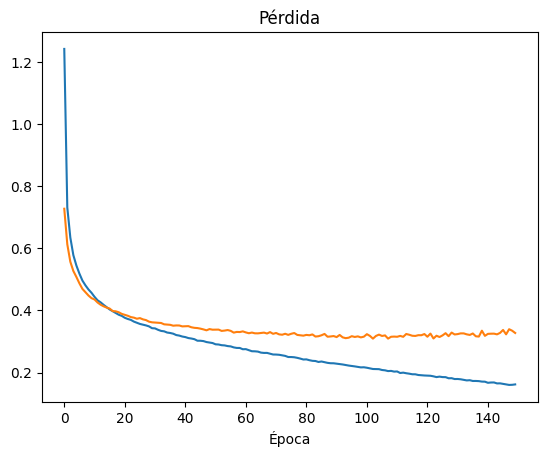

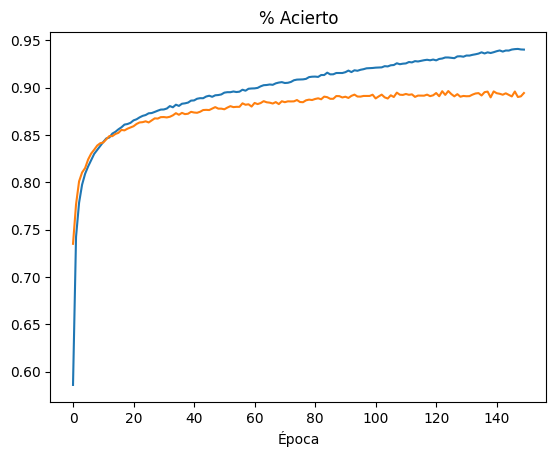

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Este bloque de código genera las gráficas de rendimiento para el segundo experimento, permitiendo ver el impacto de la técnica de Dropout. Al observar las nuevas curvas de Pérdida y % Acierto, se nota un cambio positivo. la línea del entrenamiento y la validación se mantienen mucho más cerca entre sí durante todo el proceso. Lo que nos indica debido al Dropout, logramos reducir significativamente el sobreajuste, ya que la red ya no solo memoriza los datos de practica, sino que ahora es más estable y capaz de mantener un buen desempeño ante información nueva. Por otro lado la grafica de Accuracy la brecha entre el entrenamiento y la validación se redujo notablemente que el primer modelo, lo que significa que nos indicaria que el modelo no se basa en la memorización, sino en una mejor capacidad de identificar patrones generales en las prendas que su predecesor

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.85      0.85      0.85      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.85      0.77      0.81      1000
     Vestido       0.89      0.91      0.90      1000
      Abrigo       0.75      0.90      0.82      1000
    Sandalia       0.97      0.97      0.97      1000
      Camisa       0.76      0.68      0.72      1000
   Zapatilla       0.95      0.96      0.96      1000
       Bolso       0.98      0.97      0.97      1000
       Botín       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



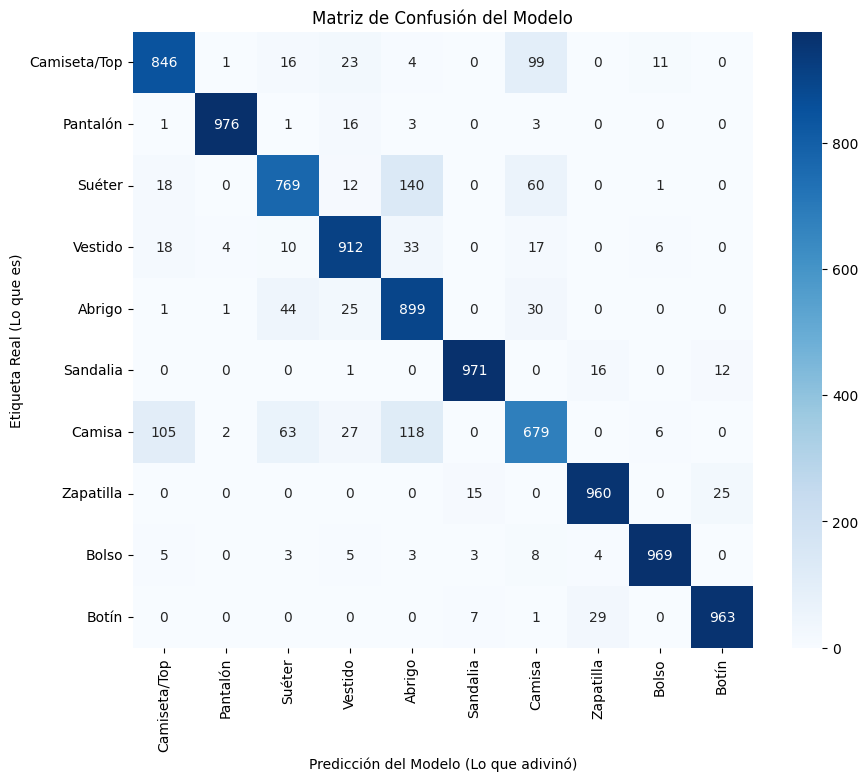

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

Este segundo modelo demuestra una mejora en el desempeño al implementar Dropout, siendo fundamental para mitigar el sobreajuste al "apagar" aleatoriamente neuronas durante el entrenamiento. Al analizar las métricas en el cuadro resumen y la matriz de confusión, se observa que la exactitud general subió al 89% y las curvas de aprendizaje se volvieron mucho más estables y cercanas entre sí, lo que confirma que el modelo ahora generaliza mejor en lugar de solo memorizar. En conclusión, este experimento entrega un sistema más robusto y estable que el primero, logrando un mejor equilibrio en la clasificación de prendas complejas como Camisetas y Vestidos

# Tercer modelo (cambio de optimizador a adam)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

En este bloque de código se define el tercer experimento, donde se mantiene la arquitectura robusta con Dropout pero se sustituye el optimizador SGD por Adam. A diferencia de los modelos anteriores, Adam es un optimizador de aprendizaje adaptativo que ajusta automáticamente la tasa de aprendizaje para cada parámetro, dirigiendose de una manera mas rápida y eficiente hacia el error mínimo. Se mantienen los mismos parametros, pero la lógica detrás de cómo la red actualiza sus pesos ahora es mas refinado, buscando maximizar la precisión en menos tiempo y con mayor estabilidad.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp3_adam_150ep.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7989 - loss: 0.5581 - val_accuracy: 0.8298 - val_loss: 0.4751
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8497 - loss: 0.4095 - val_accuracy: 0.8501 - val_loss: 0.4035
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8625 - loss: 0.3729 - val_accuracy: 0.8627 - val_loss: 0.3788
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8713 - loss: 0.3504 - val_accuracy: 0.8611 - val_loss: 0.3743
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8755 - loss: 0.3378 - val_accuracy: 0.8631 - val_loss: 0.3798
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8814 - loss: 0.3230 - val_accuracy: 0.8696 - val_loss: 0.3614
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8848 - loss: 0.3110 - val_accuracy: 0.8728 - val_loss: 0.3506
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8876 - loss: 0.3014 - 

En este bloque se ejecuta el entrenamiento del tercer modelo, manteniendo las 150 épocas y el tamaño de lote de 128 para asegurar una comparación justa con los experimentos anteriores. La diferencia fundamental es la presencia del optimizador Adam, que gestiona de manera inteligente la velocidad de aprendizaje en cada paso del proceso

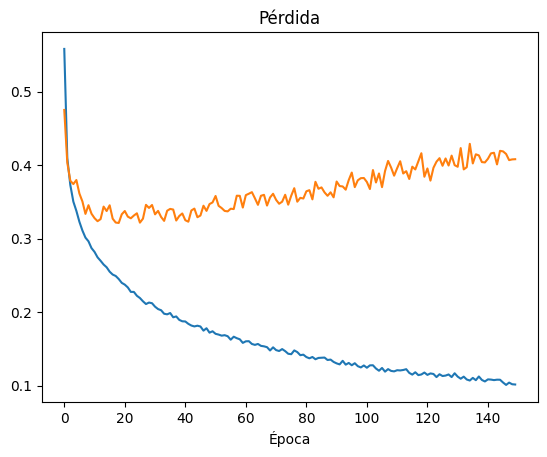

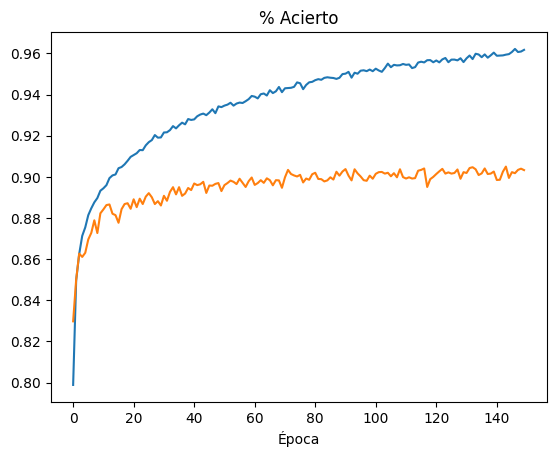

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Al ver los graficos, destaca que el optimizador Adam permite que la red encuentre los mejores resultados de forma mucho más rápida, alcanzando niveles altos de precisión con menos epocas, pero las curvas también muestran una mayor inestabilidad. En el gráfico de Pérdida, la validación presenta oscilaciones y  tiende aumentar después de 20 epocas, lo que puede indicar que, a pesar de ser muy potente "Adam", en este caso u configuracion se genera un sobreajuste (overfitting) mas evidente que los anteriores modelos con SGD y Dropout. Por otro lado, el Accuracy en validación se estabiliza rápidamente alrededor del 90%, pero la brecha con respecto al entrenamiento sugiere que la red ha comenzado a memorizar patrones del conjunto de práctica con mas agresividad.

Podemos concluir que, si bien Adam acelera el aprendizaje, requiere una supervisión mayor o una mayor regularización para evitar que la red pierda estabilidad.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.86      0.85      1000
    Pantalón       0.99      0.98      0.99      1000
      Suéter       0.87      0.81      0.84      1000
     Vestido       0.91      0.92      0.91      1000
      Abrigo       0.82      0.85      0.83      1000
    Sandalia       0.97      0.98      0.98      1000
      Camisa       0.74      0.74      0.74      1000
   Zapatilla       0.95      0.97      0.96      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.97      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



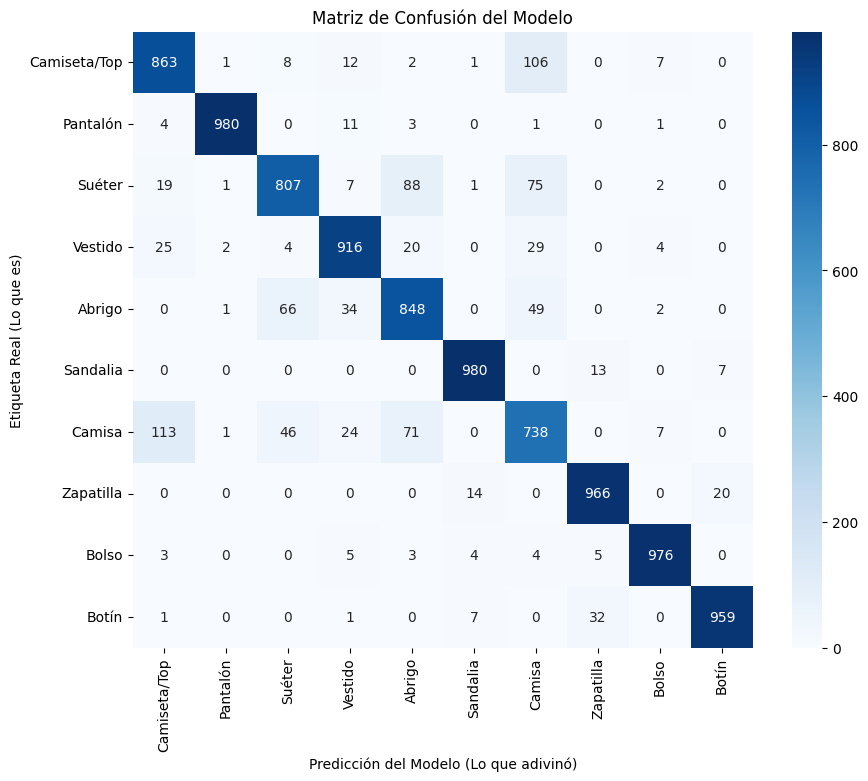

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo alcanzó una precision general (accuracy) del 90%, que sus antecesores. Se observa una mejora notable en el F1-score de categorías que a los modelos les costaba predecir, como el 'Suéter' subió a 0.84 y el 'Abrigo' a 0.83, superando los resultados del modelo con SGD.

Por otro lado en la matriz de confusion la diagonal principal muestra valores más altos de aciertos en casi todas las clases, demostrando que el optimizador Adam permitió a la red encontrar patrones de reconocimiento mejores para estos artículos y reduciendo la perdida.

Podemos decir que, El uso de Adam permitió obtener una precision del 90%, demostrando que un optimizador con tasa de aprendizaje adaptativa es ideal para esta arquitectura de 4 capas con Dropout. Aunque sigue existiendo cierta confusión natural entre prendas similares como Camisa y Camiseta/Top, el modelo es mucho más equilibrado y comete menos errores. Este experimento nos ayuda a evidenciar que la combinación de Dropout (para evitar el sobreajuste) y el optimizador Adam (para acelerar y mejorar el aprendizaje) es una configuracion bastante optima

Sin embargo, a pesar de tener una mayor precision, sus metricas de desempeño revelan una estructura inferior a la del modelo anterior. Al contrastar las gráficas Accuracy y Perdida, se observa una notable inestabilidad en la fase de validación, mostrando oscilaciones bruscas y tendiendo aumentar en la función de pérdida a partir de la época 20. Si bien Adam encuentre los mejores resultados de forma mucho más rápida, tiende a un sobreajuste (overfitting) más agresivo, alejando las curvas de entrenamiento y prueba.

# Cuarto modelo (implementacion de batch normalization)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

En este bloque se define el cuarto experimento, el cual representa la configuración de intergrar los Batch Normalization junto con las técnicas previamente validadas de Dropout y el optimizador Adam. La normalización por lotes permite reescalar las activaciones de las capas intermedias, lo que ayuda a que el entrenamiento sea menos sensible a la escala de los pesos y combatir la inestabilidad de las validaciones del anterior modelo

Se aprecia un ligero incremento en la complejidad técnica, el total de parámetros sube a 605,706, de los cuales 2,048 terminan siendo no entrenables (correspondientes a las medias y varianzas calculadas por las capas de Batch Normalization). Esta implementacion busca resolver directamente la inestabilidad del tercer modelo vista, dando una base más estable para que el optimizador Adam trabaje de forma eficiente y robusta.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp4_adam_150_BN.keras')

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8172 - loss: 0.5063 - val_accuracy: 0.8413 - val_loss: 0.4424
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8536 - loss: 0.3952 - val_accuracy: 0.8418 - val_loss: 0.4507
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8630 - loss: 0.3679 - val_accuracy: 0.8492 - val_loss: 0.4257
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8690 - loss: 0.3516 - val_accuracy: 0.8699 - val_loss: 0.3643
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8763 - loss: 0.3353 - val_accuracy: 0.8706 - val_loss: 0.3561
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8792 - loss: 0.3240 - val_accuracy: 0.8653 - val_loss: 0.3638
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8836 - loss: 0.3112 - val_accuracy: 0.8732 - val_loss: 0.3652
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8848 - loss: 0.3080 - 

Se ejecuta el entrenamiento del cuarto experimento, configurado para correr durante 150 épocas con un tamaño de lote de 128, manteniendo la misma estructura de los modelos anteriores para garantizar una comparación justa. Con la diferencia de que ahora la red debe ajustar no solo los pesos de las capas, sino también los parámetros de escala y desplazamiento introducidos por las capas de Batch Normalization

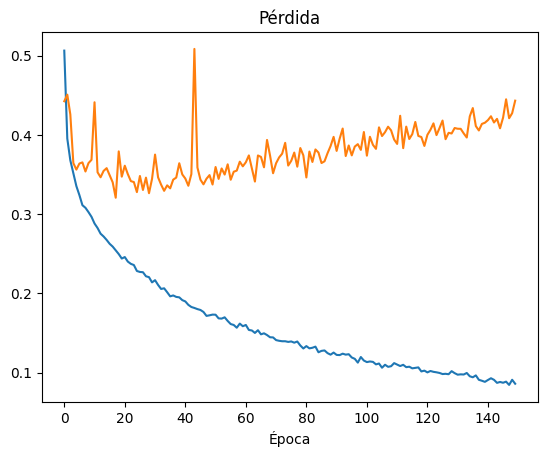

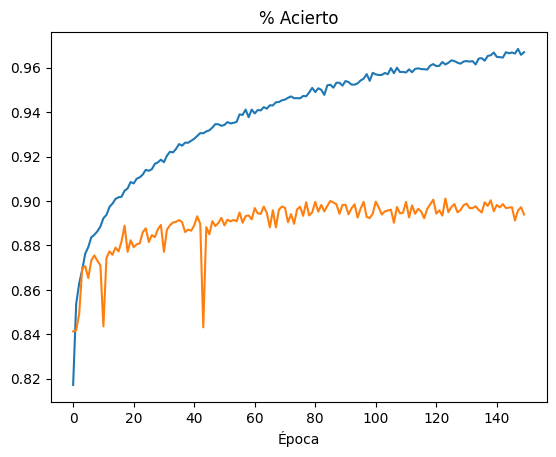

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Al observar los resultados del cuarto experimento, se puede observar lo siguiente, aunque se implementó Batch Normalization para estabilizar la red neuronal, los graficos de Perdida y Accuracy muestran una inestabilidad persistente y un sobreajuste marcado. La curva de perdida de validacion no solo presenta curvas agresivas, sino que mantiene la tendencia a subir, mientras la pérdida de entrenamiento sigue bajando, lo que indicaria que el aprendizaje es demaciado rapido con el optimizador Adam y esta superando la capacidad de regularización del modelo. Esto nos puede indicar que, para esta arquitectura específica y el dataset, la normalización por lotes no fue suficiente para frenar la inestabilidad de los resultados del optimizador, lo que nos indicaria hasta el momento el mejor modelo que a entregado resultados es el segundo modelo (SGD + Dropout), siendo más equilibrado y eficiente en términos de generalización.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.82      0.85      0.83      1000
    Pantalón       0.99      0.98      0.99      1000
      Suéter       0.80      0.85      0.82      1000
     Vestido       0.86      0.94      0.90      1000
      Abrigo       0.80      0.84      0.82      1000
    Sandalia       0.98      0.97      0.98      1000
      Camisa       0.79      0.63      0.70      1000
   Zapatilla       0.94      0.97      0.96      1000
       Bolso       0.99      0.97      0.98      1000
       Botín       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



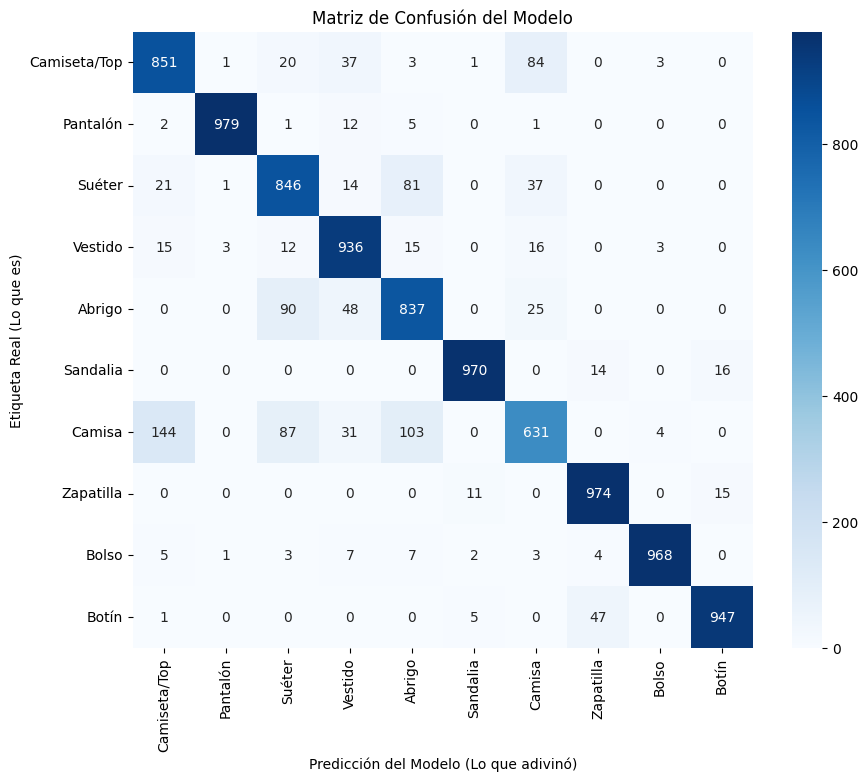

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

Al examinar el Resumen de Metricas y la Matriz de Confusión del Modelo, se puede decir que: El modelo alcanza una precisión total (accuracy) del 89%, situándose un punto por debajo del tercer modelo que usaba solo Adam. Esto confirma que la inclusión de capas de normalización, en esta configuración, no logró mejorar el limite de acierto de modelos anteriores.

Tambien podemos ver una degradación notable en la clase Camisa, cuyo F1-score bajo hasta 0.70, siendo confundida frecuentemente con Camiseta/Top (144 casos) y Abrigo (103 casos) y otras categorias mantienen sus precisiones

Podemos concluir que aunque se alla implementado capas Batch Normalization y es una tecnica potente que mejora el entrenamiento de las redes, su implementación en esta red no fue suficiente para superar la inestabilidad del optimizador Adam, tampoco logrando resolver los sobreajuste identificados en las gráficas de entrenamiento. Lo que nos da a entender que aunque se aumente la complejidad de los modelos o tecnicas no siempre garantiza mejoras

# Quinto modelo (disminucion de Batch size)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta (Recibe directamente el vector de 784)
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3)) # Apaga el 30% de las neuronas

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

# 3. Compilación
red.compile(
    loss='categorical_crossentropy', # <-- Ajuste necesario por usar to_categorical
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

En este bloque se define el quinto experimento, modelo mantiene la arquitectura avanzada del experimento anterior, manteniendo el Batch Normalization y las técnicas de Dropout y el optimizador Adam, y manteniendo la misma cantidad de parametros del anterior modelo. Pero introduce un cambio tecnico en la forma de entrenamiento ya que se reducira el Batch Size buscando resolver la inestabilidad de los modelos anteriores

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp5_adam_64_BS.keras')

Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8108 - loss: 0.5203 - val_accuracy: 0.8246 - val_loss: 0.4887
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8484 - loss: 0.4158 - val_accuracy: 0.8426 - val_loss: 0.4387
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8581 - loss: 0.3857 - val_accuracy: 0.8538 - val_loss: 0.4005
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8640 - loss: 0.3695 - val_accuracy: 0.8464 - val_loss: 0.4288
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8698 - loss: 0.3534 - val_accuracy: 0.8260 - val_loss: 0.4610
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8721 - loss: 0.3467 - val_accuracy: 0.8591 - val_loss: 0.3905
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8763 - loss: 0.3307 - val_accuracy: 0.8568 - val_loss: 0.3966
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8807 - loss: 0.3204 - val_

En esta parte se realiza el entrenamiento del quinto experimento, donde la modificación es la reducción del batch_size a 64. Al disminuir este hiperparametro a la mitad en comparación con los modelos anteriores (que usaban 128), se busca que la red actualice sus pesos con mayor frecuencia dentro de una misma época

Este cambio nos permetiria saber si el problema de inestabilidad y sobreajuste del modelo anterior se debía a una actualización de pesos demasiado lenta, o por el contrario, un lote mas pequeño aumentara la inestabilidad de las curvas de aprendizaje

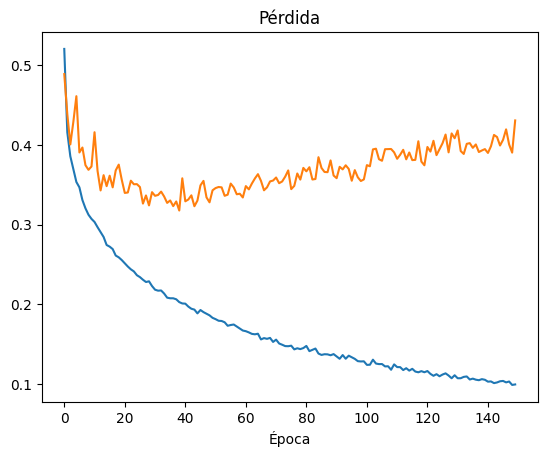

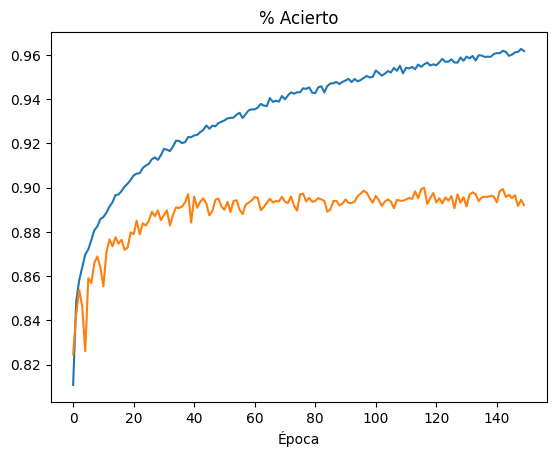

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

En la gráfica de Pérdida, se observa que la curva de entrenamiento desciende con mayor suavidad y alcanzando valroes bajos, lo cual nos queire decir que el aprendizaje fue mas profundo en los datos de entrenamiento, debido a las actualizaciones mas frecuentes de lotes.

Por otro lado en la gráfica de Accuracy, se aprecia que la precisión en la validación se estabiliza alrededor del 89-90%, indicando que el modelo ha llegado a un limite por asi decirlo de aprendizaje, donde aumentar la complejidad del modelo y ajustar los hiperparámetros ya no generan un cambio significativo en la generalización.

A pesar del uso de Batch Normalization y la reduccion de lotes, la curva de validación en ambas graficas sigue mostrando oscilaciones y una tendencia al sobreajuste (overfitting) a partir de la epoca 40 aproximadamente. Lo que nos dice que, para esta arquitectura, disminuir el tamaño del lote no fue una solucion definitiva contra la inestabilidad del optimizador Adam.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.80      0.88      0.84      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.89      0.76      0.82      1000
     Vestido       0.90      0.90      0.90      1000
      Abrigo       0.73      0.92      0.81      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.78      0.64      0.70      1000
   Zapatilla       0.95      0.95      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.94      0.96      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



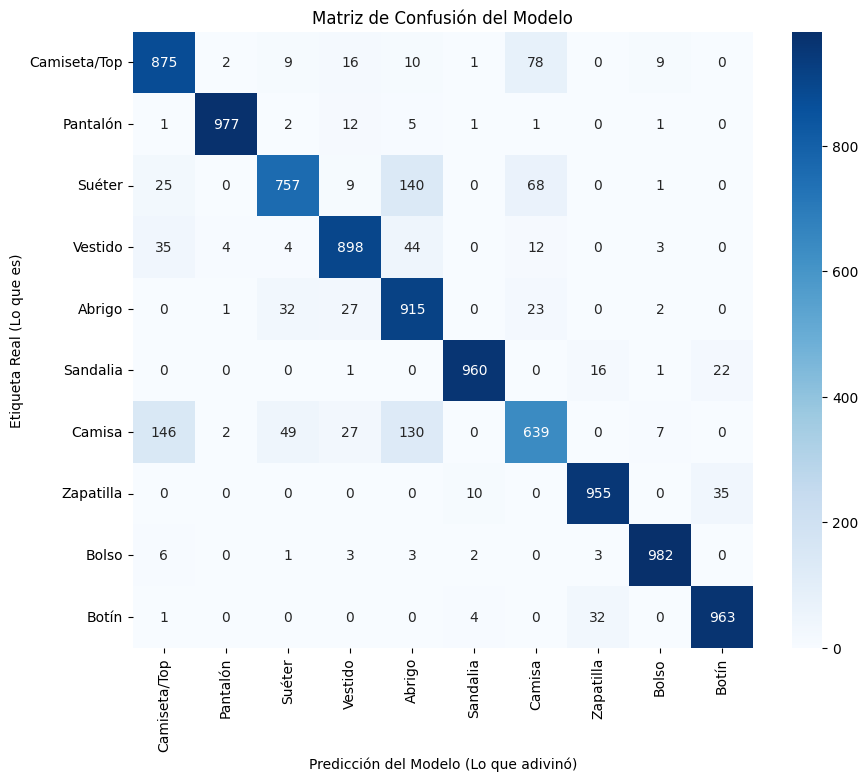

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo mantiene una precision general (accuracy) del 89%, lo que indica que duplicar la frecuencia de actualización de los pesos no fue suficiente para superar el limite de rendimiento alcanzado por modelos anteriores.

Las prendas como el Pantalón y el Bolso conservan un desempeño muy elevado con un F1-score de 0.98. Sin embargo, la Camisa continúa siendo el desafío principal del dataset, obteniendo la precision mas baja de las metricas (0.64) debido a confusiones persistentes con Camiseta/Top y Abrigo.

La Matriz de Confusión nos dice que tan bien logro clasificar la Categoria de Camisas, donde clasificó correctamente a 639 camisas, pero fallando en la identificacion de 146 como camisetas y 130 como abrigos. Esta dispersión de errores, a pesar de tener a pesar de tener una perdida minima en el entrenamiento, el modelo ha caído en un sobreajuste donde memoriza los datos de del entrenamiento pero le cuesta distinguir sutilezas entre prendas similares en el set de prueba

# Sexto Modelo Cambio de learning Rate

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

Este bloque introduce el sexto experimento, el cual busca solucionar directamente la inestabilidad observada en los modelos anteriores mediante el ajuste del Learning Rate (tasa de aprendizaje). Manteniendo la arquitectura robusta de 605,706 parámetros con Batch Normalization y Dropout, este modelo busca un equilibrio más fino entre la eficiencia y la estabilidad.

Se ha configurado manualmente el optimizador Adam con un learning_rate=0.0005. Al reducir esta tasa de aprendizaje, se busca que los ajustes de los pesos sean mas estabilidad y precision.

Este cambio busca solucionar las curvas agresivas vistas en las graficas de perdida anteriores. Un aprendizaje mas lento permitiria que las capas de Batch Normalization tenga mas control en los valores con el optimizador, evitando que el modelo de saltos bruscos en la generalizacion demasiado rapido dando soluciones inestables.

Y se mantienen las tres capas ocultas y los parametros, asegurando que cualquier mejora en el rendimiento se deba exclusivamente a la gestión del ritmo de aprendizaje.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp6_learning_rate.keras')

Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8090 - loss: 0.5320 - val_accuracy: 0.8375 - val_loss: 0.4679
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8488 - loss: 0.4124 - val_accuracy: 0.8590 - val_loss: 0.3906
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8598 - loss: 0.3810 - val_accuracy: 0.8443 - val_loss: 0.4420
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8665 - loss: 0.3599 - val_accuracy: 0.8537 - val_loss: 0.3976
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8717 - loss: 0.3450 - val_accuracy: 0.8624 - val_loss: 0.3903
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8775 - loss: 0.3307 - val_accuracy: 0.8608 - val_loss: 0.3865
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8795 - loss: 0.3224 - val_accuracy: 0.8629 - val_loss: 0.3887
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8845 - loss: 0.3087 - 

En este fragmento se ejecuta el entrenamiento del sexto experimento, manteniendo el batch_size de 64 del modelo anterior, pero operando bajo la nueva tasa de aprendizaje reducida y ejecutada por la mismas 150 epocas, se busca observar si el cambio de ritmo del aprendizaje permite reducir la inestabilidad de los modelos al generalizar.

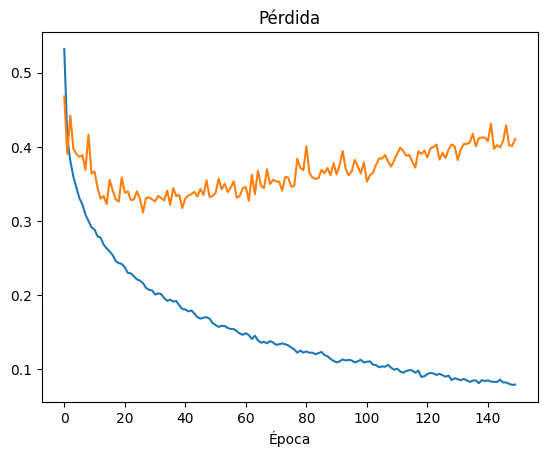

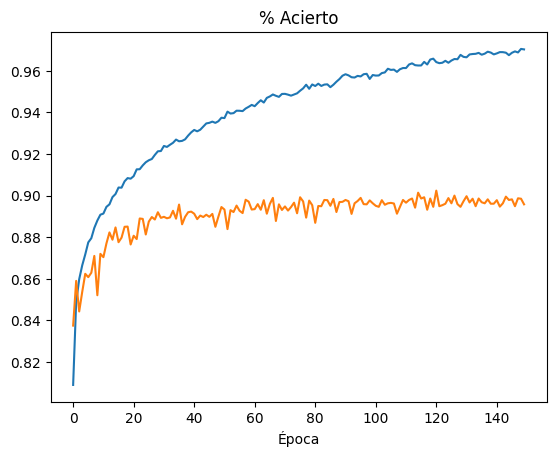

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

A diferencia de modelos anteriores, las líneas de entrenamiento en las graficas de Pérdida y Accuracy tiene una trayectoria mas suave y menos erratica. Lo que indicaria que la tasa de aprendizaje menor permitio al optimizador Adam avanzar con mayor precision.

Por otro lado el Accuracy de validación sigue manteniendose estancado cerca del 90%, ensanchando la brecha respecto al entrenamiento.

Podemos concluir que aunque el cambio de learning rate cumplio con eliminar las curvas bruscas de inestabilidad del anterior modelo(modelo 5), los resultados demuestran que esta arquitectura tiende indudablemente al overfitting con este dataset, a pesar de que se reduzca su tasa de aprendizaje.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.80      0.87      0.83      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.84      0.83      0.83      1000
     Vestido       0.90      0.91      0.91      1000
      Abrigo       0.80      0.85      0.83      1000
    Sandalia       0.98      0.95      0.97      1000
      Camisa       0.76      0.66      0.71      1000
   Zapatilla       0.93      0.97      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.96      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



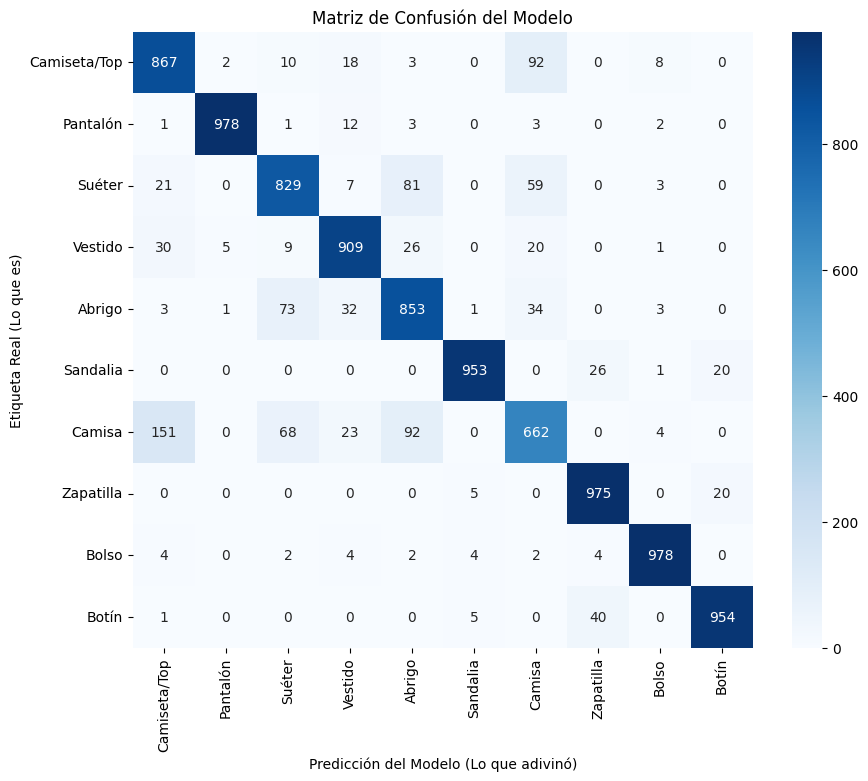

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo alcanza una precision general (accuracy) del 90%, logrando superar el estancamiento del 89% observado en los dos experimentos anteriores. Esto demuestra que un aprendizaje mas lento permitio al optimizador Adam encontrar un minimo de perdida mas efectivo en el conjunto de prueba.

Categorías como Pantalón y Bolso mantienen casi el mismo rendimiento con un F1-score de 0.98.

La Camisa presenta una leve mejoría en su recall (0.66) comparado con el modelo anterior (0.64), aunque sigue manteniendo un nivel de complejidad notable para los modelos.

Mediante la matriz de confusion podemos ver que, a pesar de la mejora general, persisten las mismas confusiones 151 camisas fueron clasificadas como Camiseta/Top y 92 como Abrigo. A pesar de ello, existe una mayor densidad en la diagonal principal de la matriz reafirmando que la calibración del learning rate fue exitosa para este nivel de complejidad.

Es posible concluir que, este sexto modelo se posicionaria como uno de los mejores y mas equilibrados de las arquitecturas probadas, logrando la mayor precisión al hacer Batch Normalization con un ritmo de aprendizaje controlado.

#Septimo modelo early stop

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

En este séptimo experimento se aplicara una una tecnica de regularización más eficientes para combatir el sobreajuste que se identifico en los experimentos previos, el Early Stopping. Se mantendra la arquitectura base y la configuración del optimizador al modelo anterior para asegurar la validez de la comparativa, el objetivo aqui es detener el entrenamiento en el momento exacto antes de que el modelo comience a memorizar el ruido de los datos.

Se conservan los mismos parámetros totales y la estructura de tres capas ocultas con Batch Normalization y Dropout,ademas se manteien el learning_rate = 0.0005 en el optimizador suavizando las curvas de aprendizaje algo que servira para la tecnica de Early Stopping y detectar con mas precision el punto de inflexion en el rendimiento del modelo. Tambien nos facilitara evaluar y verificar el efecto de la detención temprana al ser la unica variable influyente en el cambio de rendimiento permitiendo la comparacion con el modelo anterior.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp7_early_stop.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.8101 - loss: 0.5310 - val_accuracy: 0.8306 - val_loss: 0.4653
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.8489 - loss: 0.4114 - val_accuracy: 0.8522 - val_loss: 0.4065
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8582 - loss: 0.3835 - val_accuracy: 0.8558 - val_loss: 0.3846
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.8670 - loss: 0.3591 - val_accuracy: 0.8511 - val_loss: 0.3990
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8714 - loss: 0.3469 - val_accuracy: 0.8709 - val_loss: 0.3522
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8775 - loss: 0.3293 - val_accuracy: 0.8690 - val_loss: 0.3726
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8817 - loss: 0.3190 - val_accuracy: 0.8625 - val_loss: 0.3718
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8835 - loss: 0.3127 - 

En este bloque se ejecuta el entrenamiento del septimo experimento, el cual recibe un cambio notable en la gestión de las epocas. A diferencia de los modelos anteriores que se ejecutaban con 150 epocas, en este caso se ha reducido el limite a 35 epocas.

Al observar los experimentos 3, 4, 5 y 6 que la perdida de validación comenzaba a degradarse (subir) despues y entre las epocas 30-40, el uso de 35 epocas actua como una detención temprana manual. Esto evita que el modelo entre en la zona de sobreajuste critico observada antes.

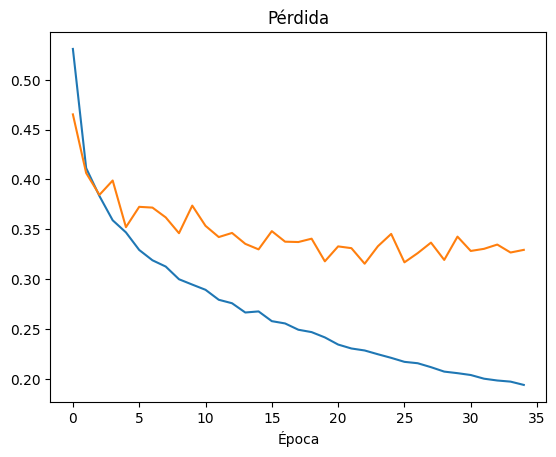

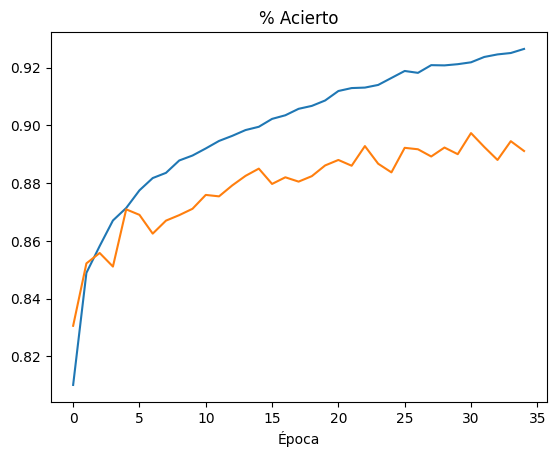

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

En la grafica de Perdida, la curva de validacion se mantiene en un rango mucho mas cercano a la de entrenamiento. Al cortar el proceso en la epoca 35, se evita que la generalizacion comience su ascenso agresivo, capturando el modelo justo antes de que el sobreajuste se vuelva evidente.

La gráfica de Accuracy muestra que la precisión en validación se estabiliza por encima del 88%. Aunque sigue existiendo una brecha respecto al entrenamiento, las oscilaciones son mucho menores que experimentos anteriores, lo que indica que el learning rate de 0.0005 y el menor numero de epocas logro una mayor eficiencia y precision.

ademas podemos decir que alrededor de la epoca 30, el rendimiento en validacion empieza a mostrar signos de estancamiento. Esto afirma que extender el entrenamiento a 150 epocas, como se hizo anteriormente, hacia que el modelo o la red memorizara ruido sin aportar valor real a la clasificación de nuevas imagenes.

Y podemos concluir que, Este modelo es tecnicamente mas robusto porque logra casi la misma eficacia que anteriores modelos, y reduciendo el sobreajuste o ruidos.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.82      0.88      0.85      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.84      0.78      0.81      1000
     Vestido       0.88      0.90      0.89      1000
      Abrigo       0.75      0.88      0.81      1000
    Sandalia       0.99      0.95      0.97      1000
      Camisa       0.77      0.64      0.70      1000
   Zapatilla       0.93      0.98      0.96      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



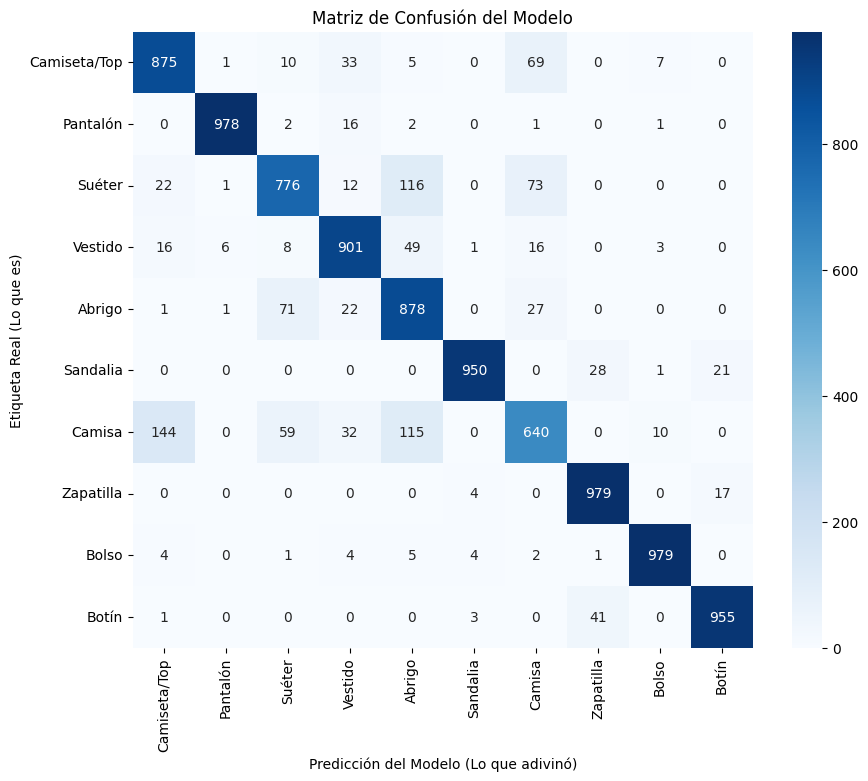

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo alcanza una precision general del 89%. Esto demuestra que entrenar solo 35 epocas llega hacer suficiente para igualar el rendimiento de modelos que corrieron durante 150 epocas, permitiendo optimizar los recursos de computo.

La categoría Camisa presenta un recall de 0.64 y un F1-score de 0.70. Por otro lado la matriz de confusión revela que la red aun confunde frecuentemente las camisas con Camiseta/Top (144 casos) y Abrigo (115 casos). Al no permitir que el modelo se sobreajuste, los errores se concentran en las similitudes de las prendas.

Esta especie de equilibrio entre las metricas de precisión y recall sugiere que el modelo ha aprendido patrones abstractos mas relevantes en lugar de memorizar el ruido del set de entrenamiento.

Y podemos concluir que, este septimo experimento valida que la calidad de la generalización no depende de la cantidad de epocas, sino de capturar el estado optimo de los pesos.

#Modelo 8 cambio de funcion de activacion

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

Este octavo modelo se realiza un cambio en la configuracion del modelo sustituyendo la función de activación ReLU por la sigmoide en todas las capas ocultas. A diferencia de ReLU, la función sigmoide transforma las salidas de cada neurona en un rango de (0, 1). Aunque esto suele ralentizar el aprendizaje debido al problema del desvanecimiento del gradiente, pero en conjunto con Batch Normalization, se buscara ver si el modelo logra una estabilidad superior o una mayor eficiencia en este conjunto de datos.

Se conservan tanto los parametros totales y el optimizador Adam asegurando que cualquier variación en el rendimiento sea solo por el cambio de la funcion de activacion y no al tamaño de la red. Configuración de Entrenamiento: Se mantiene el optimizador Adam con el learning_rate=0.0005 validado en los experimentos 6 y 7, proporcionando un entorno de control justo para comparar si la sigmoide ayuda a mitigar el sobreajuste o si, por el contrario, limita demasiado la capacidad de aprendizaje de la red.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp8_sigmoid.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.8117 - loss: 0.5286 - val_accuracy: 0.8252 - val_loss: 0.4943
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8506 - loss: 0.4144 - val_accuracy: 0.8455 - val_loss: 0.4403
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8637 - loss: 0.3747 - val_accuracy: 0.8547 - val_loss: 0.4145
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8735 - loss: 0.3488 - val_accuracy: 0.8631 - val_loss: 0.3809
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.8797 - loss: 0.3298 - val_accuracy: 0.8602 - val_loss: 0.3890
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8839 - loss: 0.3131 - val_accuracy: 0.8709 - val_loss: 0.3700
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8886 - loss: 0.2983 - val_accuracy: 0.8697 - val_loss: 0.3587
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8931 - loss: 0.2870 - 

En este bloque se realiza el entrenamiento para el octavo modelo es el lo que nos permitira observar como la función de activación sigmoide afecta la velocidad y la calidad del aprendizaje en comparación con los modelos anteriores que utilizaron ReLU.

A diferencia de los experimentos previos, el uso de la sigmoide en las tres capas ocultas hace que lograr el minimo de error sea mas lenta. Se busca verificar si la red logra alcanzar niveles de precisión similares al 89% o mayores, en solo 35 epocas.

Dado que la sigmoide es propensa al desvanecimiento del gradiente, atraves de las capas de Bacth Normalization permitira que este entrenamiento sea viable, manteniendo las activaciones en un rango donde los gradientes no se anulen.

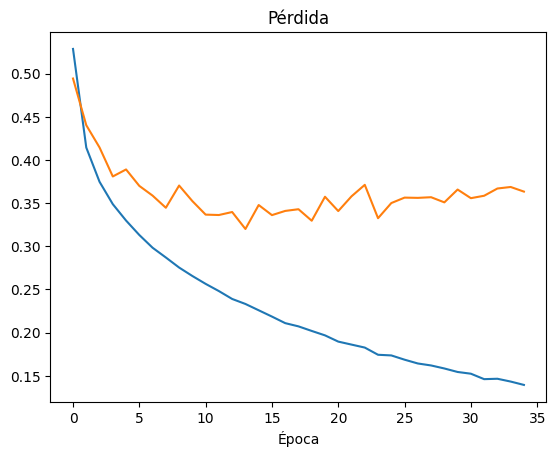

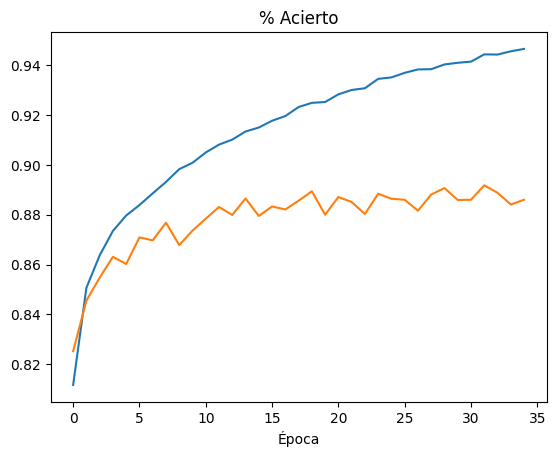

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Las graficas del octavo modelo revela el impacto que tuvo al cambiar la funcion de activacion a sigmoide, mostrando un comportamiento distinto en la forma de aprendizaje respecto a los modelos anteriores basados en ReLU.

En la grafica de Perdida se ve que en la validacion deja de descender significativamente alrededor de la epoca 10, estabilizandose en un nivel superior al de entrenamiento.

A pesar de usar funciones sigmoides, que son mas lentas en el aprendizaje, la brecha entre el entrenamiento y la validacion sigue manteniendose y siendo notable en ambas graficas, y que sigue memorizando el ruido de los datos a pesar de las regularizaciones y cambios hechos.

Es posible notar que aunque el entrenamiento sigue subiendo hacia el 95%, la validacion no logra romper ese limite, lo que indica que el cambio de activacion no necesariamente mejoro la capacidad de generalización frente al modelo anterior, pero tampoco empeoro notablemente.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.83      0.84      0.84      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.85      0.74      0.79      1000
     Vestido       0.89      0.90      0.89      1000
      Abrigo       0.73      0.89      0.81      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.73      0.65      0.68      1000
   Zapatilla       0.94      0.97      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



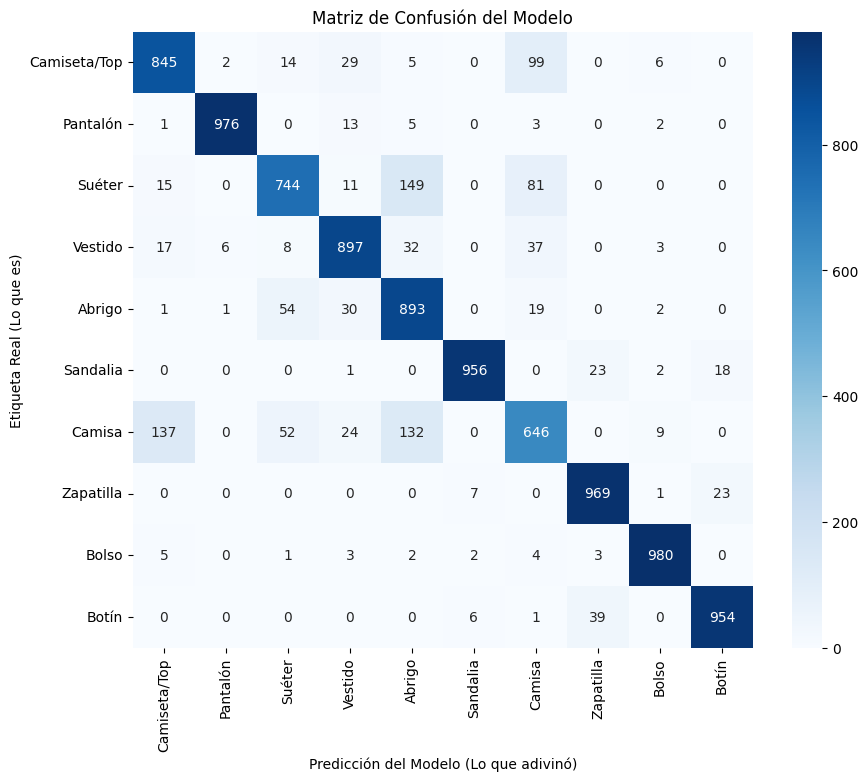

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo mantiene un 0.89, lo que indica que, a pesar del cambio de funcion de activacion, el rendimiento general es identico al del séptimo modelo bajo las mismas epocas.

La clase Camisa sigue siendo el desafio principal, con un recall de 0.65 y un F1-score de 0.68. Aunque el recall subio un punto respecto al modelo anterior (0.64), la precisión bajo de 0.77 a 0.73, sugiriendo que la sigmoide tiende a ser menos exacta con esta categoría.

Analizando la matriz de confusion el modelo sigue confundiendo las prendas como la Camisa siendo clasificada como Camiseta/Top en 137 ocasiones y como Abrigo en 132 casos.

Y sigue existiendo una confusion significativa entre el Suéter y el Abrigo, lo llegando hacer incluso superior a lo observado en modelos con ReLU aunque esto ultimo suelen ser una diferencia minima.

#modelo 9: numero de capas

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

mi_optimizador = Adam(learning_rate=0.0005)

# Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,890 (2.06 MB)

 Trainable params: 537,354 (2.05 MB)

 Non-trainable params: 1,536 (6.00 KB)

En este noveno experimento, se evaluó el impacto estructural de la red al modificar el hiperparámetro correspondiente al número de capas. Tomando como base la configuración del modelo más estable hasta el momento, se procedió a eliminar la tercera capa oculta, transformando la arquitectura en una red más "superficial" de solo dos capas ocultas.

observaremos si una menor cantidad de parámetros entrenables es capaz de mantener el nivel de generalización reduciendo el esfuerzo de cómputo, o si la pérdida de esa tercera capa disminuye drásticamente la capacidad de la red para extraer características de las prendas.

In [ ]:

hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp9_menos_capas.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8099 - loss: 0.5268 - val_accuracy: 0.8226 - val_loss: 0.5035
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8492 - loss: 0.4135 - val_accuracy: 0.8427 - val_loss: 0.4547
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8620 - loss: 0.3789 - val_accuracy: 0.8532 - val_loss: 0.4181
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8687 - loss: 0.3599 - val_accuracy: 0.8537 - val_loss: 0.3972
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8733 - loss: 0.3459 - val_accuracy: 0.8507 - val_loss: 0.3969
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8737 - loss: 0.3378 - val_accuracy: 0.8650 - val_loss: 0.3758
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8799 - loss: 0.3230 - val_accuracy: 0.8717 - val_loss: 0.3540
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8845 - loss: 0.3135 - 

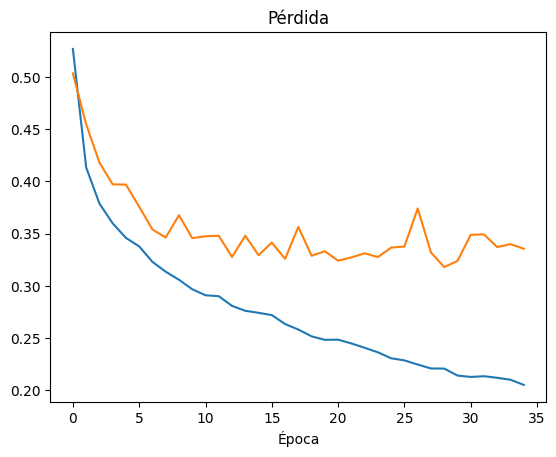

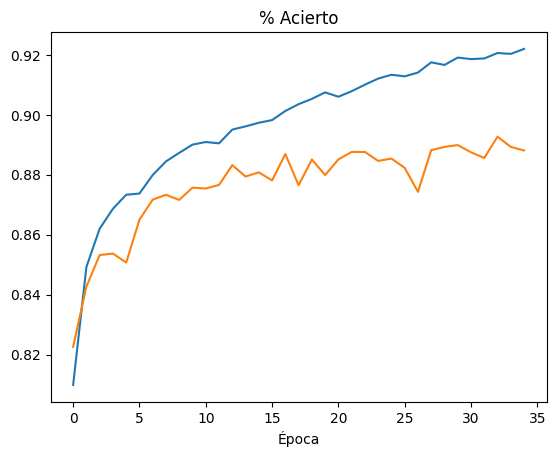

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se puede ver la disminucion de capas no significa una gran perdida de precision del modelo e incluso dando mejores resultados respecto a la metrica de val_loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.79      0.89      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.82      0.78      0.80      1000
     Vestido       0.93      0.86      0.90      1000
      Abrigo       0.78      0.85      0.82      1000
    Sandalia       0.99      0.95      0.97      1000
      Camisa       0.72      0.65      0.68      1000
   Zapatilla       0.93      0.98      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.97      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



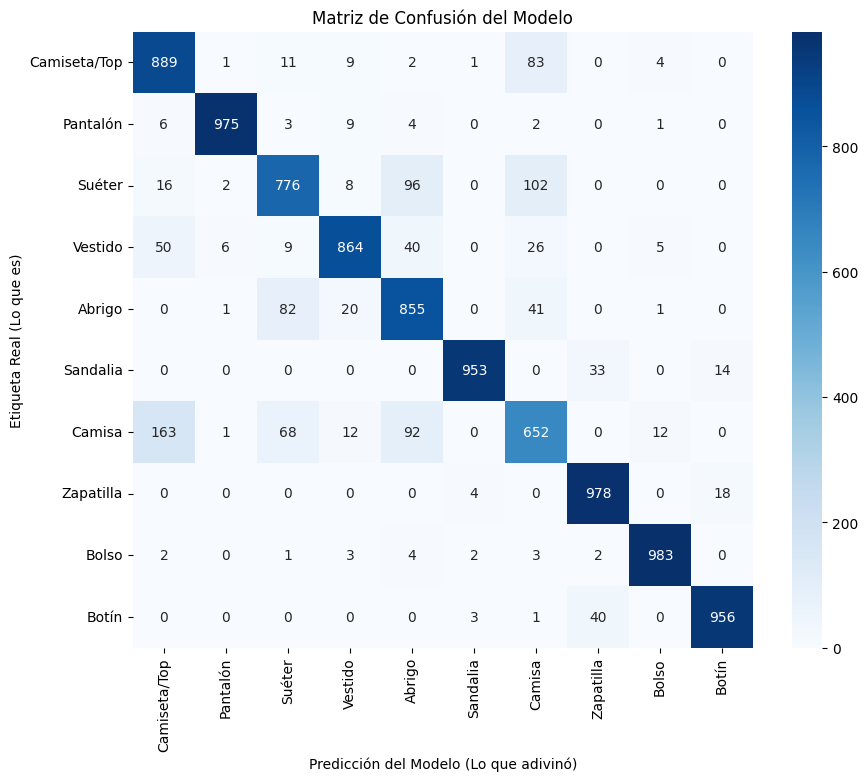

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

Viendo estos resultados podemos concluir que segun el contexto y el problema no siempre es mejor mayor cantidad de capas, si no que incluso puede llegar a ser beneficioso, en este caso esto puede significar que una arquitectura de mayor capas sea demasiado grande y profunda dando la oportunidad al modelo de en vez de aprender, memorizar,dando peores resultados para un dataset como este.

#modelo 10 funcion de error

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='kl_divergence',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

Para el Experimento 10, se evaluó el comportamiento de la red utilizando KL Divergence como función de error, en lugar de la Categorical Crossentropy estándar.

la Divergencia KL es una métrica que evalúa qué tan diferente es la suposición de nuestro modelo en comparación con la realidad de los datos.

La Divergencia KL no mide un error lineal tradicional, sino que calcula el "costo" adicional en términos de información. Si el modelo asume que el mundo funciona según una distribución, pero en la realidad funciona según otra distribución, la métrica evalúa cuánta "sorpresa" o ineficiencia genera esa suposición incorrecta.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp10_kl_divergence.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8436 - loss: 0.4321 - val_accuracy: 0.8442 - val_loss: 0.4467
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8564 - loss: 0.3908 - val_accuracy: 0.8535 - val_loss: 0.4005
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8643 - loss: 0.3696 - val_accuracy: 0.8425 - val_loss: 0.4510
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8709 - loss: 0.3540 - val_accuracy: 0.8506 - val_loss: 0.4089
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8738 - loss: 0.3386 - val_accuracy: 0.8635 - val_loss: 0.3712
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8801 - loss: 0.3220 - val_accuracy: 0.8641 - val_loss: 0.3793
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8820 - loss: 0.3172 - val_accuracy: 0.8703 - val_loss: 0.3540
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8860 - loss: 0.3054 - 

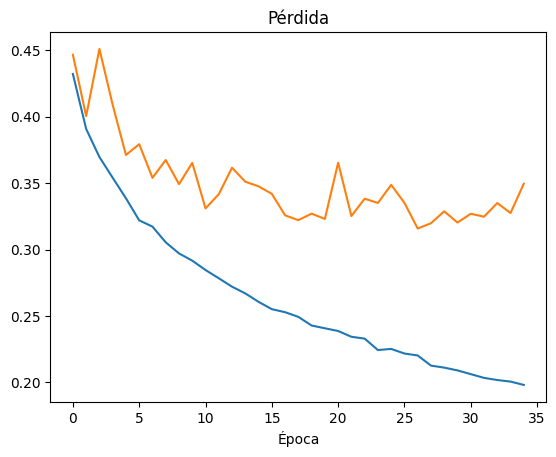

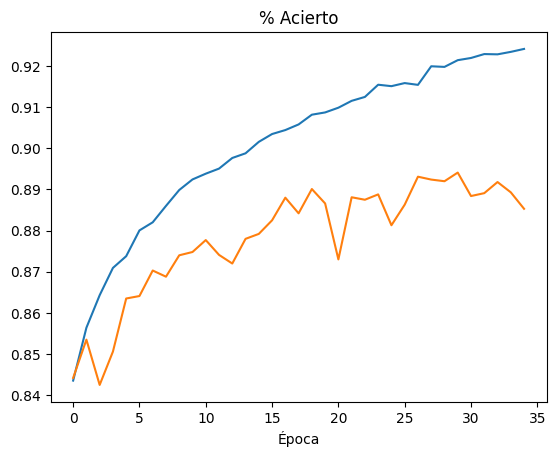

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.86      0.85      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.87      0.74      0.80      1000
     Vestido       0.88      0.92      0.90      1000
      Abrigo       0.74      0.89      0.81      1000
    Sandalia       0.99      0.93      0.96      1000
      Camisa       0.76      0.67      0.71      1000
   Zapatilla       0.88      0.98      0.93      1000
       Bolso       0.97      0.98      0.97      1000
       Botín       0.96      0.91      0.94      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



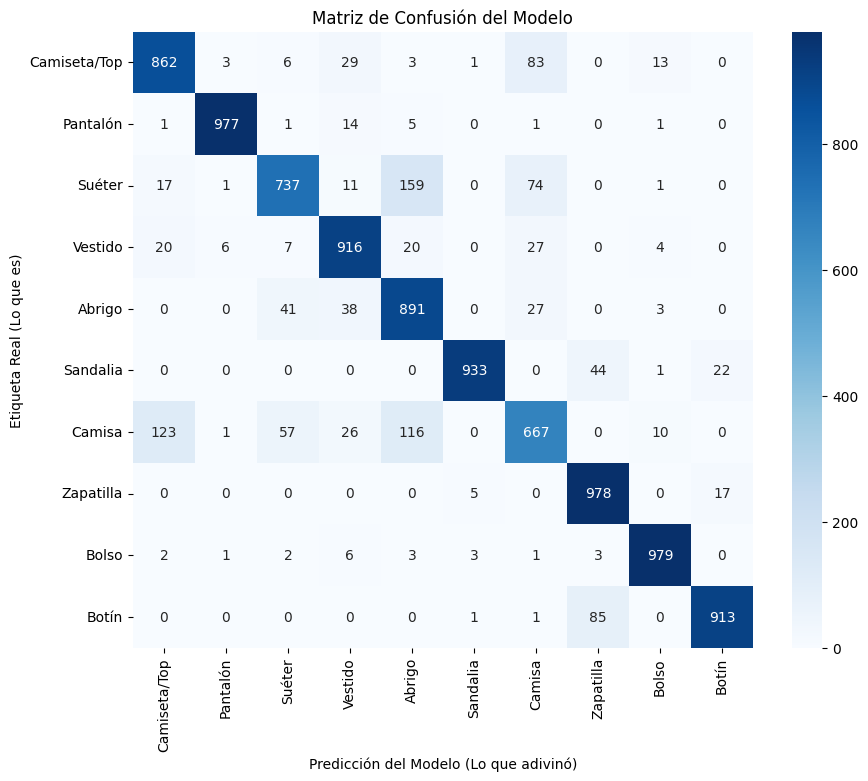

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo alcanzó una precisión casi idéntico al obtenido con Crossentropy. Esto demuestra que, para un problema de clasificación multiclase como Fashion-MNIST, ambas funciones de error son igual de efectivas para guiar el aprendizaje.



# Tabla comparativa

In [ ]:
import pandas as pd
from IPython.display import display

historial_experimentos = []
historial_experimentos.append({
    'Modelo': 'Exp 1: Base (SGD)',
    'Épocas': 150, 'LR': '0.01 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '88.0%',
    'Val Loss': '0.42',
    'Observación Principal': 'Convergencia constante pero con evidente overfitting.'
})
historial_experimentos.append({
    'Modelo': 'Exp 2: Dropout (SGD)',
    'Épocas': 150, 'LR': '0.01 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '89.4%',
    'Val Loss': '0.32',
    'Observación Principal': 'Mejora la generalización; curvas de aprendizaje mucho más estables.'
})
historial_experimentos.append({
    'Modelo': 'Exp 3: Adam',
    'Épocas': 150, 'LR': '0.001 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '90.3%',
    'Val Loss': '0.40',
    'Observación Principal': 'Aprendizaje más rápido pero genera inestabilidad y sobreajuste agresivo.'
})
historial_experimentos.append({
    'Modelo': 'Exp 4: Batch Normalization',
    'Épocas': 150, 'LR': '0.001 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '89.3%',
    'Val Loss': '0.44',
    'Observación Principal': 'No logra frenar la inestabilidad de Adam; el overfitting persiste.'
})
historial_experimentos.append({
    'Modelo': 'Exp 5: Batch Size Reducido',
    'Épocas': 150, 'LR': '0.001 (Defecto)', 'Batch Size': 64,
    'Val Accuracy': '89.2%',
    'Val Loss': '0.43',
    'Observación Principal': 'Aprendizaje más profundo en train, pero no soluciona la oscilación en validación.'
})
historial_experimentos.append({
    'Modelo': 'Exp 6: Learning Rate Reducido',
    'Épocas': 150, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '89.5%',
    'Val Loss': '0.41',
    'Observación Principal': 'Elimina curvas bruscas. Aprendizaje suave, pero el modelo tiende al overfitting a largo plazo.'
})
historial_experimentos.append({
    'Modelo': 'Exp 7: Early Stopping',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '89.5%',
    'Val Loss': '0.32',
    'Observación Principal': 'Detención en punto óptimo. Máxima eficiencia mitigando por completo el sobreajuste tardío.'
})
historial_experimentos.append({
    'Modelo': 'Exp 8: Activación Sigmoide',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '88.9%',
    'Val Loss': '0.36',
    'Observación Principal': 'Aprendizaje más lento y propenso a desvanecimiento del gradiente; menor precisión en clases complejas.'
})
historial_experimentos.append({
    'Modelo': 'Exp 9: disminucion de capas',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '88,8%',
    'Val Loss': '0.33',
    'Observación Principal': 'Al reducir las capas, el modelo entrenó rápido y mantuvo un accuracy decente (88.8%) con baja pérdida (0.33), demostrando que una red menos profunda también es viable para este problema'
})
historial_experimentos.append({
    'Modelo': 'Exp 10: kl_divergence',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '89,4%',
    'Val Loss': '0.34',
    'Observación Principal': 'modelo alcanzó un desempeño idéntico al de Categorical Crossentropy'
})

tabla_comparativa = pd.DataFrame(historial_experimentos)
display(tabla_comparativa)

,Modelo,Épocas,LR,Batch Size,Val Accuracy,Val Loss,Observación Principal
0,Exp 1: Base (SGD),150,0.01 (Defecto),128,88.0%,0.42,Convergencia constante pero con evidente overf...
1,Exp 2: Dropout (SGD),150,0.01 (Defecto),128,89.4%,0.32,Mejora la generalización; curvas de aprendizaj...
2,Exp 3: Adam,150,0.001 (Defecto),128,90.3%,0.40,Aprendizaje más rápido pero genera inestabilid...
3,Exp 4: Batch Normalization,150,0.001 (Defecto),128,89.3%,0.44,No logra frenar la inestabilidad de Adam; el o...
4,Exp 5: Batch Size Reducido,150,0.001 (Defecto),64,89.2%,0.43,"Aprendizaje más profundo en train, pero no sol..."
5,Exp 6: Learning Rate Reducido,150,0.0005,64,89.5%,0.41,"Elimina curvas bruscas. Aprendizaje suave, per..."
6,Exp 7: Early Stopping,35,0.0005,64,89.5%,0.32,Detención en punto óptimo. Máxima eficiencia m...
7,Exp 8: Activación Sigmoide,35,0.0005,64,88.9%,0.36,Aprendizaje más lento y propenso a desvanecimi...
8,Exp 9: disminucion de capas,35,0.0005,64,"88,8%",0.33,"Al reducir las capas, el modelo entrenó rápido..."
9,Exp 10: kl_divergence,35,0.0005,64,"89,4%",0.34,modelo alcanzó un desempeño idéntico al de Cat...


#Conclusion

Tras desarrollar y evaluar una serie de experimentos controlados sobre la arquitectura del Perceptrón Multicapa para el dataset Fashion-MNIST, se determina que el Experimento 7 (implementación de Early Stopping) es el modelo mas optimo segun los experimentos llevados a cabo.

Aunque este modelo alcanzó un val_accuracy del 89.5% (ligeramente inferior al pico de 90.3% del modelo con Adam base) es el modelo con la mayor capacidad de generalizacion, ya que no se le da el suficiente tiempo para memorizar como tambien deberia de tener la capacidad de un rapido procesamiento al utilizar pocas epocas.

Como trabajo futuro y propuesta de mejora, el siguiente paso lógico sería transicionar a una arquitectura CNN para conseguir una mayor precision en las las predicciones, especialmente en el apartado de las camisas.



#Demo modelo

Modelo '/content/modelo_exp7_early_stop.keras' cargado exitosamente.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


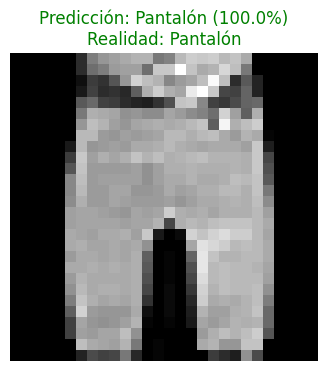

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


nombres_clases = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


nombre_archivo = '/content/modelo_exp7_early_stop.keras'
try:
    modelo_cargado = tf.keras.models.load_model(nombre_archivo)
    print(f"Modelo '{nombre_archivo}' cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")


_, (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


x_test = x_test / 255.0


indice_random = random.randint(0, len(x_test) - 1)
imagen_demo = x_test[indice_random]
etiqueta_real = y_test[indice_random]


imagen_batch = imagen_demo.reshape(1, 784)

predicciones = modelo_cargado.predict(imagen_batch)


indice_prediccion = np.argmax(predicciones[0])
confianza = np.max(predicciones[0]) * 100


plt.figure(figsize=(4,4))
plt.imshow(imagen_demo, cmap='gray')
plt.axis('off')


color = 'green' if indice_prediccion == etiqueta_real else 'red'

plt.title(f"Predicción: {nombres_clases[indice_prediccion]} ({confianza:.1f}%)\n"
          f"Realidad: {nombres_clases[etiqueta_real]}", color=color)

plt.show()